In [1]:
import os

# Dataset path check karo
path = "/kaggle/input"
print("Available datasets:")
for folder in os.listdir(path):
    print(f"  📁 {folder}")

Available datasets:
  📁 datasets


In [2]:
import os

base = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"

cancer = 0
no_cancer = 0
skipped = 0

for patient in os.listdir(base):
    patient_path = os.path.join(base, patient)
    if os.path.isdir(patient_path):
        c0 = os.path.join(patient_path, "0")
        c1 = os.path.join(patient_path, "1")
        if os.path.exists(c0):
            no_cancer += len(os.listdir(c0))
        if os.path.exists(c1):
            cancer += len(os.listdir(c1))
        else:
            skipped += 1

total = cancer + no_cancer
print(f"✅ Cancer     (class 1): {cancer:,}")
print(f"✅ No Cancer  (class 0): {no_cancer:,}")
print(f"📊 Total images:         {total:,}")
print(f"⚖️  Imbalance ratio:      1 : {no_cancer/cancer:.2f}")

✅ Cancer     (class 1): 78,786
✅ No Cancer  (class 0): 198,738
📊 Total images:         277,524
⚖️  Imbalance ratio:      1 : 2.52


Data cleaning
step one Corrupt images check****

In [3]:
from PIL import Image
import os
from tqdm import tqdm

base = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"

corrupt = []

all_images = []
for patient in os.listdir(base):
    for label in ["0", "1"]:
        folder = os.path.join(base, patient, label)
        if os.path.exists(folder):
            for img in os.listdir(folder):
                all_images.append(os.path.join(folder, img))

print(f"Total images to check: {len(all_images):,}")

for path in tqdm(all_images, desc="Checking corrupt images"):
    try:
        img = Image.open(path)
        img.verify()
    except Exception as e:
        corrupt.append(path)

print(f"\n✅ Corrupt images found: {len(corrupt)}")
if corrupt:
    for c in corrupt[:5]:
        print(f"  ❌ {c}")

Total images to check: 277,524


Checking corrupt images: 100%|██████████| 277524/277524 [36:23<00:00, 127.08it/s]


✅ Corrupt images found: 0


Pehle sirf clean DataFrame banao:****

In [4]:
import os
import pandas as pd

base = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"

all_images = []
for patient in os.listdir(base):
    for label in ["0", "1"]:
        folder = os.path.join(base, patient, label)
        if os.path.exists(folder):
            for img in os.listdir(folder):
                if img.endswith(".png"):
                    all_images.append({
                        "path": os.path.join(folder, img),
                        "patient_id": patient,
                        "label": int(label)
                    })

df = pd.DataFrame(all_images)

print(f"Total rows:    {len(df):,}")
print(f"Total columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nData types:")
print(df.dtypes)
print(f"\nNull values:")
print(df.isnull().sum())

Total rows:    277,524
Total columns: ['path', 'patient_id', 'label']

First 3 rows:
                                                path patient_id  label
0  /kaggle/input/datasets/paultimothymooney/breas...      10295      0
1  /kaggle/input/datasets/paultimothymooney/breas...      10295      0
2  /kaggle/input/datasets/paultimothymooney/breas...      10295      0

Data types:
path          object
patient_id    object
label          int64
dtype: object

Null values:
path          0
patient_id    0
label         0
dtype: int64


In [5]:
import numpy as np
from PIL import Image
from tqdm import tqdm

sample = df.sample(n=5000, random_state=42)

wrong_size = []

for _, row in tqdm(sample.iterrows(), total=5000, desc="Size check"):
    try:
        img = Image.open(row["path"])
        if img.size != (50, 50):
            wrong_size.append({
                "path": row["path"],
                "size": img.size
            })
    except:
        pass

print(f"\n📊 SIZE CHECK REPORT (5000 sample)")
print(f"{'='*40}")
print(f"✅ Wrong size images: {len(wrong_size)}")

if len(wrong_size) > 0:
    wrong_df = pd.DataFrame(wrong_size)
    print(wrong_df["size"].value_counts())

Size check: 100%|██████████| 5000/5000 [00:05<00:00, 867.69it/s]


📊 SIZE CHECK REPORT (5000 sample)
✅ Wrong size images: 36
size
(50, 42)    5
(50, 41)    3
(50, 28)    3
(50, 40)    2
(50, 38)    2
(50, 7)     2
(50, 24)    2
(50, 1)     2
(50, 37)    1
(50, 23)    1
(50, 43)    1
(50, 13)    1
(50, 16)    1
(50, 8)     1
(50, 15)    1
(50, 26)    1
(50, 27)    1
(50, 29)    1
(2, 50)     1
(50, 14)    1
(50, 36)    1
(50, 34)    1
(50, 11)    1
Name: count, dtype: int64


In [6]:
from PIL import Image
import pandas as pd
from tqdm import tqdm

fixed = 0
failed = 0

# Poori dataset pe size fix karo - sirf wrong size wali
wrong_paths = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Finding wrong size"):
    try:
        img = Image.open(row["path"])
        if img.size != (50, 50):
            wrong_paths.append(row["path"])
    except:
        failed += 1

print(f"\nTotal wrong size found: {len(wrong_paths):,}")
print(f"Total unreadable:       {failed}")
print(f"\n✅ These will be resized to (50,50) during training")
print(f"✅ No images deleted — resize on-the-fly in DataLoader")

Finding wrong size: 100%|██████████| 277524/277524 [07:06<00:00, 651.09it/s] 


Total wrong size found: 2,302
Total unreadable:       0

✅ These will be resized to (50,50) during training
✅ No images deleted — resize on-the-fly in DataLoader


In [7]:
from PIL import Image
import numpy as np
from tqdm import tqdm

sample = df.sample(n=5000, random_state=42)

blank_images = []

for _, row in tqdm(sample.iterrows(), total=5000, desc="Blank/Dark check"):
    try:
        img = Image.open(row["path"]).convert("RGB")
        arr = np.array(img)
        mean_val = arr.mean()
        
        if mean_val < 10:
            blank_images.append({"path": row["path"], "mean": mean_val, "type": "Too Dark"})
        elif mean_val > 245:
            blank_images.append({"path": row["path"], "mean": mean_val, "type": "Too Bright"})
            
    except:
        pass

print(f"\n📊 BLANK/DARK CHECK REPORT (5000 sample)")
print(f"{'='*40}")
print(f"✅ Blank/Dark images found: {len(blank_images)}")

if len(blank_images) > 0:
    blank_df = pd.DataFrame(blank_images)
    print(blank_df["type"].value_counts())
    print(f"\nSample:")
    print(blank_df.head(3))

Blank/Dark check: 100%|██████████| 5000/5000 [00:04<00:00, 1096.53it/s]


📊 BLANK/DARK CHECK REPORT (5000 sample)
✅ Blank/Dark images found: 0


In [8]:
import hashlib
import numpy as np
from PIL import Image
from tqdm import tqdm

sample = df.sample(n=5000, random_state=42)

hashes = {}
duplicates = []

for _, row in tqdm(sample.iterrows(), total=5000, desc="Duplicate check"):
    try:
        img = Image.open(row["path"]).convert("RGB")
        arr = np.array(img)
        h = hashlib.md5(arr.tobytes()).hexdigest()
        
        if h in hashes:
            duplicates.append({
                "duplicate": row["path"],
                "original": hashes[h],
                "label_dup": row["label"]
            })
        else:
            hashes[h] = row["path"]
            
    except:
        pass

print(f"\n📊 DUPLICATE CHECK REPORT (5000 sample)")
print(f"{'='*40}")
print(f"✅ Duplicate images found: {len(duplicates)}")

if len(duplicates) > 0:
    dup_df = pd.DataFrame(duplicates)
    print(dup_df.head(5))

Duplicate check: 100%|██████████| 5000/5000 [00:04<00:00, 1079.78it/s]


📊 DUPLICATE CHECK REPORT (5000 sample)
✅ Duplicate images found: 0


In [9]:
print(f"\n📊 LABEL VALIDITY CHECK (Full dataset)")
print(f"{'='*40}")

# Sirf 0 aur 1 honi chahiye
unique_labels = df["label"].unique()
print(f"Unique labels found: {unique_labels}")

invalid_labels = df[~df["label"].isin([0, 1])]
print(f"Invalid labels:      {len(invalid_labels)}")

print(f"\nLabel distribution:")
label_counts = df["label"].value_counts()
print(f"  Class 0 (No Cancer): {label_counts[0]:,}")
print(f"  Class 1 (Cancer):    {label_counts[1]:,}")

print(f"\nClass balance:")
print(f"  Cancer %:    {label_counts[1]/len(df)*100:.1f}%")
print(f"  No Cancer %: {label_counts[0]/len(df)*100:.1f}%")


📊 LABEL VALIDITY CHECK (Full dataset)
Unique labels found: [0 1]
Invalid labels:      0

Label distribution:
  Class 0 (No Cancer): 198,738
  Class 1 (Cancer):    78,786

Class balance:
  Cancer %:    28.4%
  No Cancer %: 71.6%


In [10]:
import numpy as np
from PIL import Image
from tqdm import tqdm

sample = df.sample(n=5000, random_state=42)

invalid_pixels = []

for _, row in tqdm(sample.iterrows(), total=5000, desc="Pixel check"):
    try:
        img = Image.open(row["path"]).convert("RGB")
        arr = np.array(img, dtype=np.float32)
        
        # Pixel range 0-255 hona chahiye
        if arr.min() < 0 or arr.max() > 255:
            invalid_pixels.append({
                "path": row["path"],
                "min": arr.min(),
                "max": arr.max()
            })
            
        # NaN check
        if np.isnan(arr).any():
            invalid_pixels.append({
                "path": row["path"],
                "min": "NaN",
                "max": "NaN"
            })
            
    except:
        pass

print(f"\n📊 PIXEL VALIDITY CHECK (5000 sample)")
print(f"{'='*40}")
print(f"✅ Invalid pixel images found: {len(invalid_pixels)}")

if len(invalid_pixels) > 0:
    inv_df = pd.DataFrame(invalid_pixels)
    print(inv_df.head(5))

Pixel check: 100%|██████████| 5000/5000 [00:04<00:00, 1073.68it/s]


📊 PIXEL VALIDITY CHECK (5000 sample)
✅ Invalid pixel images found: 0


In [11]:
df.to_csv("cleaned_dataset.csv", index=False)
print(f"✅ Cleaned dataset saved!")
print(f"   Total images: {len(df):,}")
print(f"   Columns: {df.columns.tolist()}")

✅ Cleaned dataset saved!
   Total images: 277,524
   Columns: ['path', 'patient_id', 'label']


In [12]:
from PIL import Image

sample_paths = df.sample(n=500, random_state=42)["path"].tolist()

channel_counts = {}

for path in sample_paths:
    try:
        img = Image.open(path)
        mode = img.mode
        channel_counts[mode] = channel_counts.get(mode, 0) + 1
    except:
        pass

print(f"\n📊 CHANNEL CHECK (500 sample)")
print(f"{'='*40}")
for mode, count in channel_counts.items():
    print(f"  {mode}: {count}")


📊 CHANNEL CHECK (500 sample)
  RGB: 500


In [13]:
total_patients = df["patient_id"].nunique()
images_per_patient = df.groupby("patient_id").size()

print(f"\n📊 PATIENT LEAKAGE CHECK")
print(f"{'='*40}")
print(f"Total unique patients: {total_patients}")
print(f"\nImages per patient:")
print(f"  Min:    {images_per_patient.min()}")
print(f"  Max:    {images_per_patient.max()}")
print(f"  Mean:   {images_per_patient.mean():.1f}")
print(f"\nPatients with both classes:")
both = df.groupby("patient_id")["label"].nunique()
print(f"  Both 0 & 1: {(both == 2).sum()}")
print(f"  Only 0:     {(both == 1).sum()}")


📊 PATIENT LEAKAGE CHECK
Total unique patients: 279

Images per patient:
  Min:    63
  Max:    2395
  Mean:   994.7

Patients with both classes:
  Both 0 & 1: 279
  Only 0:     0


In [14]:
df.to_csv("/kaggle/working/cleaned_dataset.csv", index=False)
print(f"✅ Saved: {len(df):,} images")

✅ Saved: 277,524 images


 EDA        Step 1 — Class Distribution se shuru karte hain:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

df = pd.read_csv("/kaggle/working/cleaned_dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
classes = ["No Cancer (0)", "Cancer (1)"]
counts = [df["label"].value_counts()[0], df["label"].value_counts()[1]]
colors = ["#2ecc71", "#e74c3c"]

axes[0].bar(classes, counts, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(counts):
    axes[0].text(i, v + 1000, f"{v:,}\n({v/len(df)*100:.1f}%)", 
                ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts, labels=classes, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Class Balance", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Class distribution done")

✅ Class distribution done


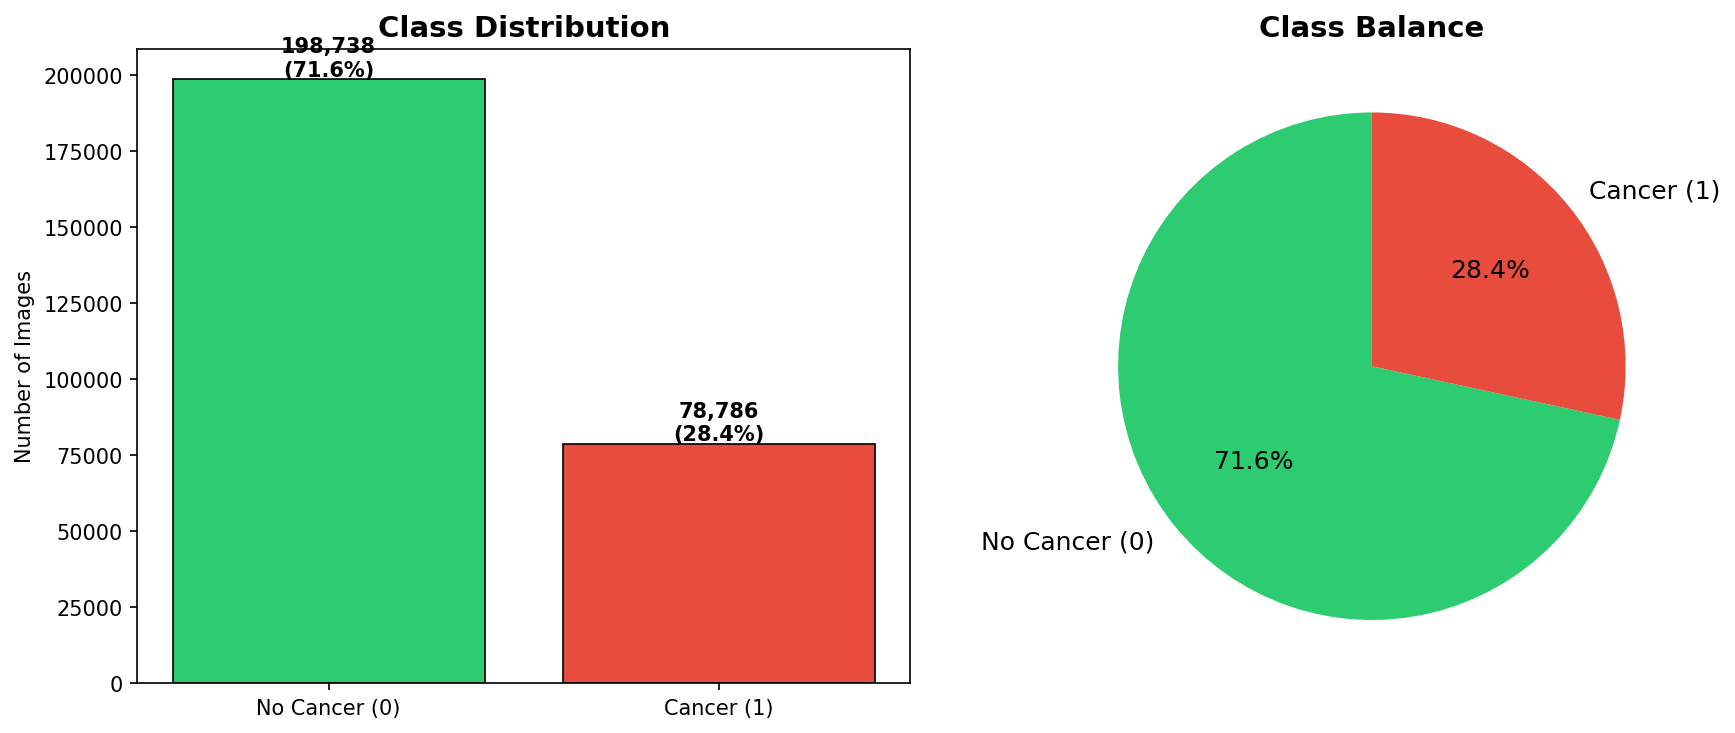

In [16]:
from IPython.display import Image
Image("/kaggle/working/eda_class_distribution.png")

Step 2 — Patient Distribution

In [17]:
import matplotlib.pyplot as plt
import numpy as np

patient_counts = df.groupby("patient_id").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Images per patient histogram
axes[0].hist(patient_counts.values, bins=30, color="#3498db", edgecolor="black", linewidth=0.8)
axes[0].set_title("Images per Patient", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Images")
axes[0].set_ylabel("Number of Patients")
axes[0].axvline(patient_counts.mean(), color="red", linestyle="--", label=f"Mean: {patient_counts.mean():.0f}")
axes[0].legend()

# Cancer ratio per patient
cancer_ratio = df.groupby("patient_id")["label"].mean().sort_values(ascending=False)
axes[1].hist(cancer_ratio.values, bins=20, color="#e74c3c", edgecolor="black", linewidth=0.8)
axes[1].set_title("Cancer Ratio per Patient", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Cancer Ratio (0=No Cancer, 1=All Cancer)")
axes[1].set_ylabel("Number of Patients")
axes[1].axvline(cancer_ratio.mean(), color="blue", linestyle="--", label=f"Mean: {cancer_ratio.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/eda_patient_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Patient distribution done")
print(f"   Min images/patient:  {patient_counts.min()}")
print(f"   Max images/patient:  {patient_counts.max()}")
print(f"   Mean cancer ratio:   {cancer_ratio.mean():.2f}")

✅ Patient distribution done
   Min images/patient:  63
   Max images/patient:  2395
   Mean cancer ratio:   0.31


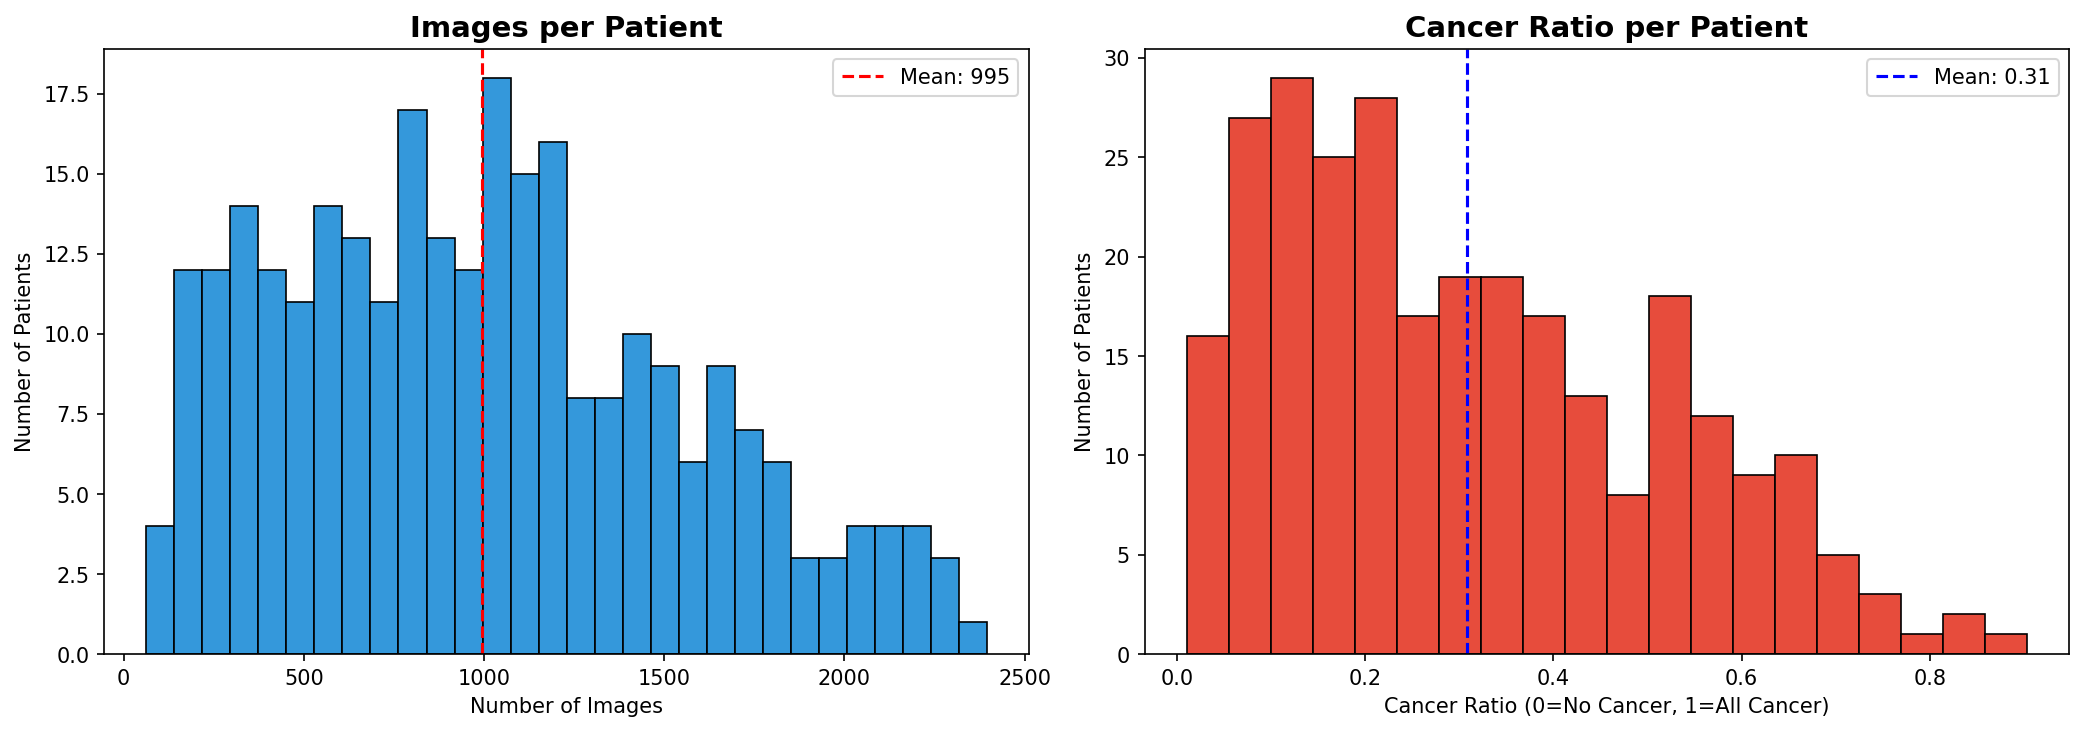

In [18]:
from IPython.display import Image
Image("/kaggle/working/eda_patient_distribution.png")

Step 3 — Sample Images Visualization — cancer vs non-cancer kaisi dikhti hain:

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage

fig, axes = plt.subplots(2, 8, figsize=(16, 5))

cancer_samples = df[df["label"] == 1].sample(n=8, random_state=42)
normal_samples = df[df["label"] == 0].sample(n=8, random_state=42)

for i, (_, row) in enumerate(cancer_samples.iterrows()):
    img = PILImage.open(row["path"]).convert("RGB").resize((50, 50))
    axes[0, i].imshow(np.array(img))
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Cancer (1)", fontsize=11, 
                             fontweight="bold", color="red", loc="left")

for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = PILImage.open(row["path"]).convert("RGB").resize((50, 50))
    axes[1, i].imshow(np.array(img))
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("No Cancer (0)", fontsize=11,
                             fontweight="bold", color="green", loc="left")

plt.suptitle("Sample Images — Cancer vs No Cancer", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/eda_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample images done")


✅ Sample images done


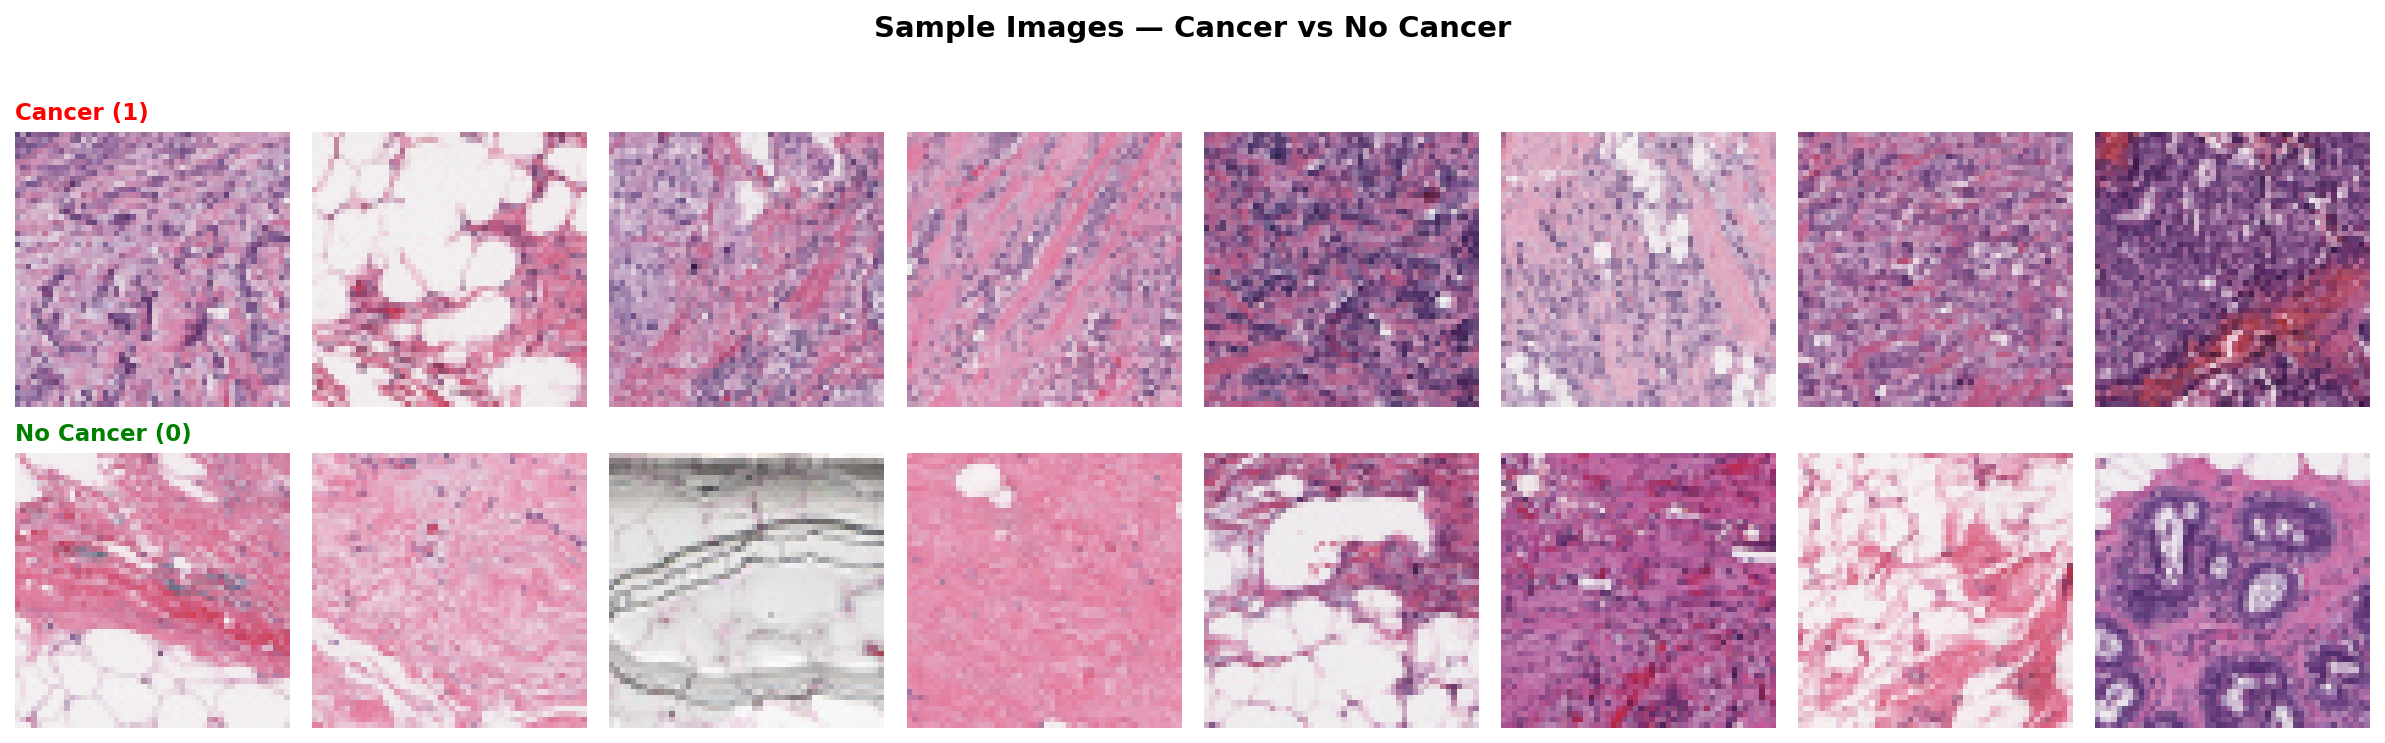

In [20]:
from IPython.display import Image
Image("/kaggle/working/eda_sample_images.png")

Step 4 — Pixel Intensity Analysis:

In [21]:
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt
from tqdm import tqdm

cancer_pixels = []
normal_pixels = []

cancer_sample = df[df["label"] == 1].sample(n=300, random_state=42)
normal_sample = df[df["label"] == 0].sample(n=300, random_state=42)

for _, row in tqdm(cancer_sample.iterrows(), total=300, desc="Cancer pixels"):
    img = np.array(PILImage.open(row["path"]).convert("RGB").resize((50,50)))
    cancer_pixels.append(img.mean())

for _, row in tqdm(normal_sample.iterrows(), total=300, desc="Normal pixels"):
    img = np.array(PILImage.open(row["path"]).convert("RGB").resize((50,50)))
    normal_pixels.append(img.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_pixels, bins=30, color="#2ecc71", alpha=0.7, label="No Cancer", edgecolor="black", linewidth=0.5)
axes[0].hist(cancer_pixels, bins=30, color="#e74c3c", alpha=0.7, label="Cancer", edgecolor="black", linewidth=0.5)
axes[0].set_title("Pixel Intensity Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Mean Pixel Value")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].axvline(np.mean(normal_pixels), color="green", linestyle="--")
axes[0].axvline(np.mean(cancer_pixels), color="red", linestyle="--")

axes[1].boxplot([normal_pixels, cancer_pixels], 
                labels=["No Cancer", "Cancer"],
                patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Pixel Intensity Boxplot", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Mean Pixel Value")

plt.tight_layout()
plt.savefig("/kaggle/working/eda_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Pixel analysis done")
print(f"   Cancer mean pixel:    {np.mean(cancer_pixels):.2f}")
print(f"   No Cancer mean pixel: {np.mean(normal_pixels):.2f}")

Normal pixels: 100%|██████████| 300/300 [00:00<00:00, 1018.31it/s]
/tmp/ipykernel_25/899433488.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal_pixels, cancer_pixels],


✅ Pixel analysis done
   Cancer mean pixel:    166.20
   No Cancer mean pixel: 190.96


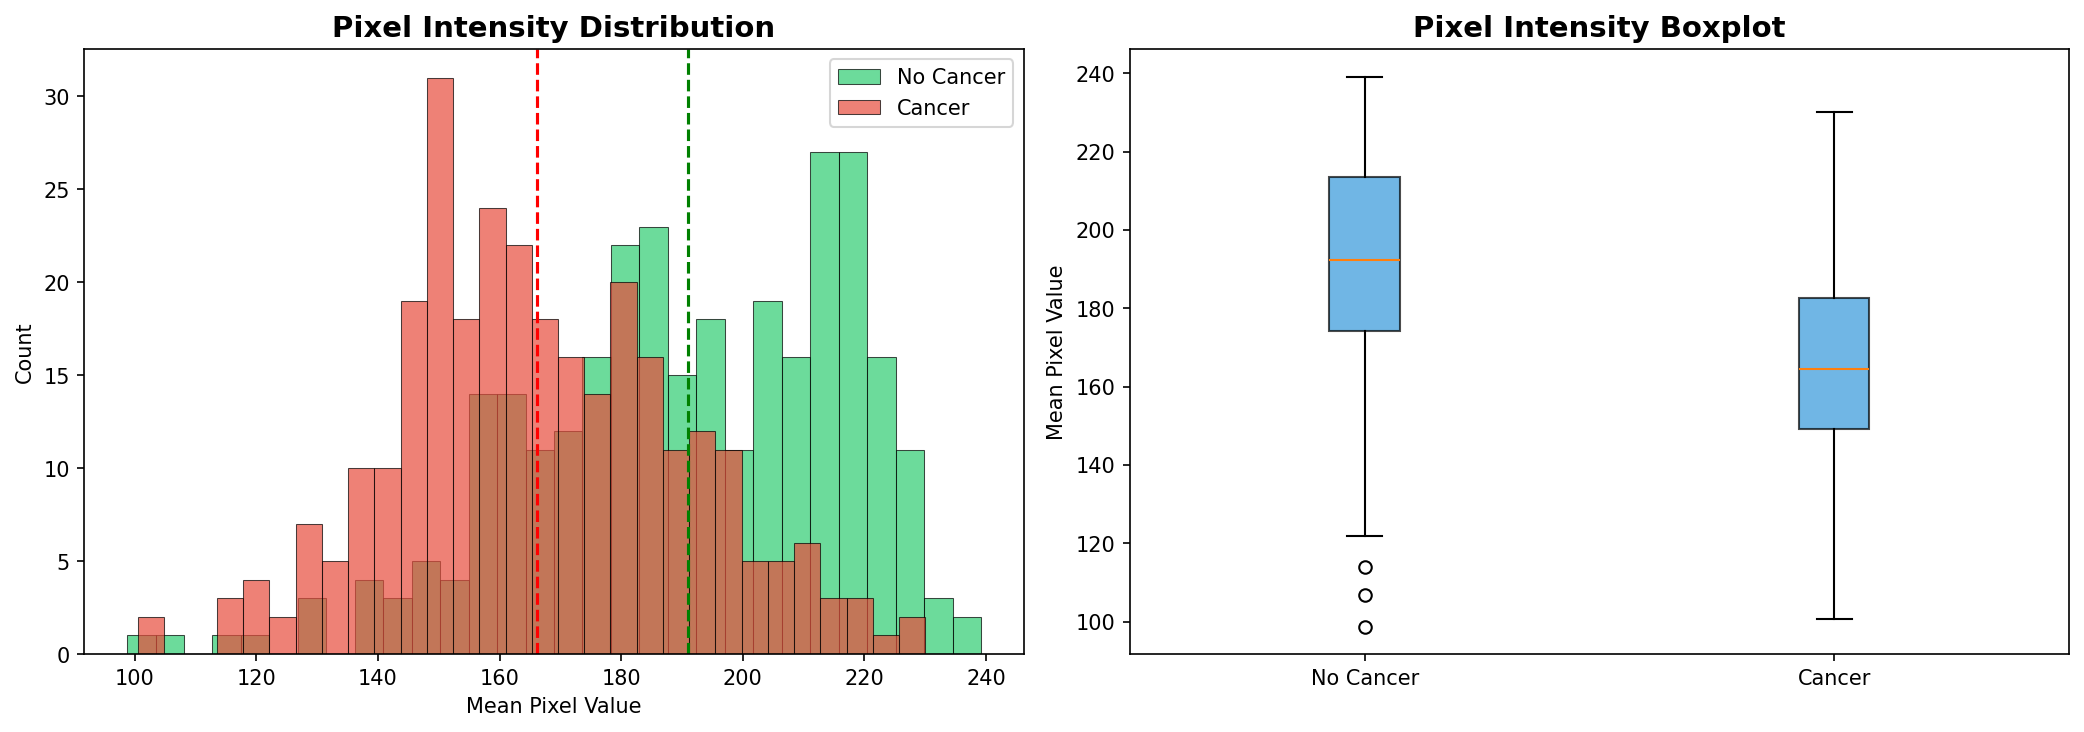

In [22]:
from IPython.display import Image
Image("/kaggle/working/eda_pixel_intensity.png")

Step 5 — Image Statistics per Class:


In [23]:
import numpy as np
from PIL import Image as PILImage
from tqdm import tqdm
import matplotlib.pyplot as plt

stats = {"cancer": {"r":[], "g":[], "b":[], "std":[]},
         "normal": {"r":[], "g":[], "b":[], "std":[]}}

cancer_s = df[df["label"]==1].sample(n=300, random_state=42)
normal_s = df[df["label"]==0].sample(n=300, random_state=42)

for _, row in tqdm(cancer_s.iterrows(), total=300, desc="Cancer stats"):
    arr = np.array(PILImage.open(row["path"]).convert("RGB").resize((50,50)))
    stats["cancer"]["r"].append(arr[:,:,0].mean())
    stats["cancer"]["g"].append(arr[:,:,1].mean())
    stats["cancer"]["b"].append(arr[:,:,2].mean())
    stats["cancer"]["std"].append(arr.std())

for _, row in tqdm(normal_s.iterrows(), total=300, desc="Normal stats"):
    arr = np.array(PILImage.open(row["path"]).convert("RGB").resize((50,50)))
    stats["normal"]["r"].append(arr[:,:,0].mean())
    stats["normal"]["g"].append(arr[:,:,1].mean())
    stats["normal"]["b"].append(arr[:,:,2].mean())
    stats["normal"]["std"].append(arr.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channels = ["R", "G", "B"]
cancer_means = [np.mean(stats["cancer"]["r"]), 
                np.mean(stats["cancer"]["g"]),
                np.mean(stats["cancer"]["b"])]
normal_means = [np.mean(stats["normal"]["r"]),
                np.mean(stats["normal"]["g"]),
                np.mean(stats["normal"]["b"])]

x = np.arange(3)
axes[0].bar(x-0.2, normal_means, 0.4, label="No Cancer", color="#2ecc71", edgecolor="black")
axes[0].bar(x+0.2, cancer_means, 0.4, label="Cancer", color="#e74c3c", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(channels)
axes[0].set_title("RGB Channel Means", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Mean Value")
axes[0].legend()

axes[1].boxplot([stats["normal"]["std"], stats["cancer"]["std"]],
                tick_labels=["No Cancer", "Cancer"],
                patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Texture (Std Dev per Image)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Standard Deviation")

plt.tight_layout()
plt.savefig("/kaggle/working/eda_image_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Image stats done")
print(f"\nR channel  — Cancer: {np.mean(stats['cancer']['r']):.1f}  No Cancer: {np.mean(stats['normal']['r']):.1f}")
print(f"G channel  — Cancer: {np.mean(stats['cancer']['g']):.1f}  No Cancer: {np.mean(stats['normal']['g']):.1f}")
print(f"B channel  — Cancer: {np.mean(stats['cancer']['b']):.1f}  No Cancer: {np.mean(stats['normal']['b']):.1f}")
print(f"Texture    — Cancer: {np.mean(stats['cancer']['std']):.1f}  No Cancer: {np.mean(stats['normal']['std']):.1f}")

Normal stats: 100%|██████████| 300/300 [00:00<00:00, 981.02it/s] 


✅ Image stats done

R channel  — Cancer: 187.0  No Cancer: 214.2
G channel  — Cancer: 138.7  No Cancer: 168.1
B channel  — Cancer: 172.9  No Cancer: 190.7
Texture    — Cancer: 36.9  No Cancer: 37.5


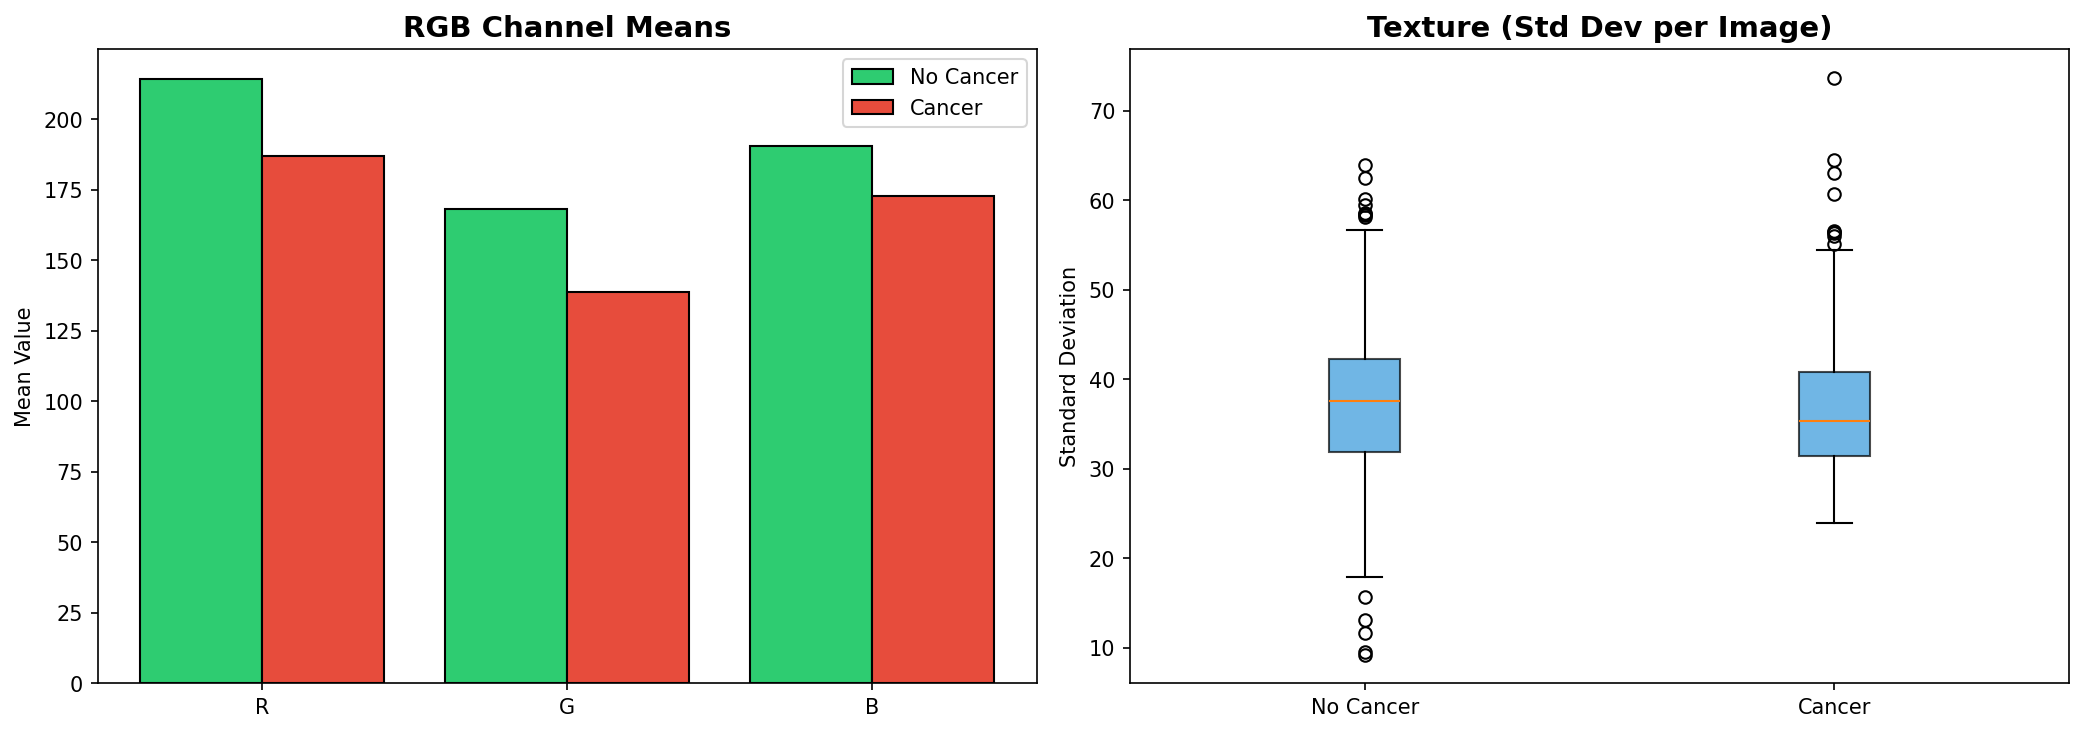

In [24]:
from IPython.display import Image
Image("/kaggle/working/eda_image_stats.png")

Step 6 — Spatial Analysis 

In [25]:
import numpy as np
from PIL import Image as PILImage
from tqdm import tqdm
import matplotlib.pyplot as plt

cancer_heatmap = np.zeros((50, 50))
normal_heatmap = np.zeros((50, 50))

cancer_s = df[df["label"]==1].sample(n=500, random_state=42)
normal_s = df[df["label"]==0].sample(n=500, random_state=42)

for _, row in tqdm(cancer_s.iterrows(), total=500, desc="Cancer spatial"):
    arr = np.array(PILImage.open(row["path"]).convert("RGB").resize((50,50)))
    cancer_heatmap += arr.mean(axis=2)

for _, row in tqdm(normal_s.iterrows(), total=500, desc="Normal spatial"):
    arr = np.array(PILImage.open(row["path"]).convert("RGB").resize((50,50)))
    normal_heatmap += arr.mean(axis=2)

cancer_heatmap /= 500
normal_heatmap /= 500

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im1 = axes[0].imshow(normal_heatmap, cmap="RdYlGn", vmin=100, vmax=220)
axes[0].set_title("No Cancer — Avg Intensity", fontsize=13, fontweight="bold")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(cancer_heatmap, cmap="RdYlGn", vmin=100, vmax=220)
axes[1].set_title("Cancer — Avg Intensity", fontsize=13, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

diff = normal_heatmap - cancer_heatmap
im3 = axes[2].imshow(diff, cmap="coolwarm")
axes[2].set_title("Difference Map", fontsize=13, fontweight="bold")
axes[2].axis("off")
plt.colorbar(im3, ax=axes[2])

plt.suptitle("Spatial Intensity Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/eda_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Spatial analysis done")

Normal spatial: 100%|██████████| 500/500 [00:00<00:00, 741.98it/s]


✅ Spatial analysis done


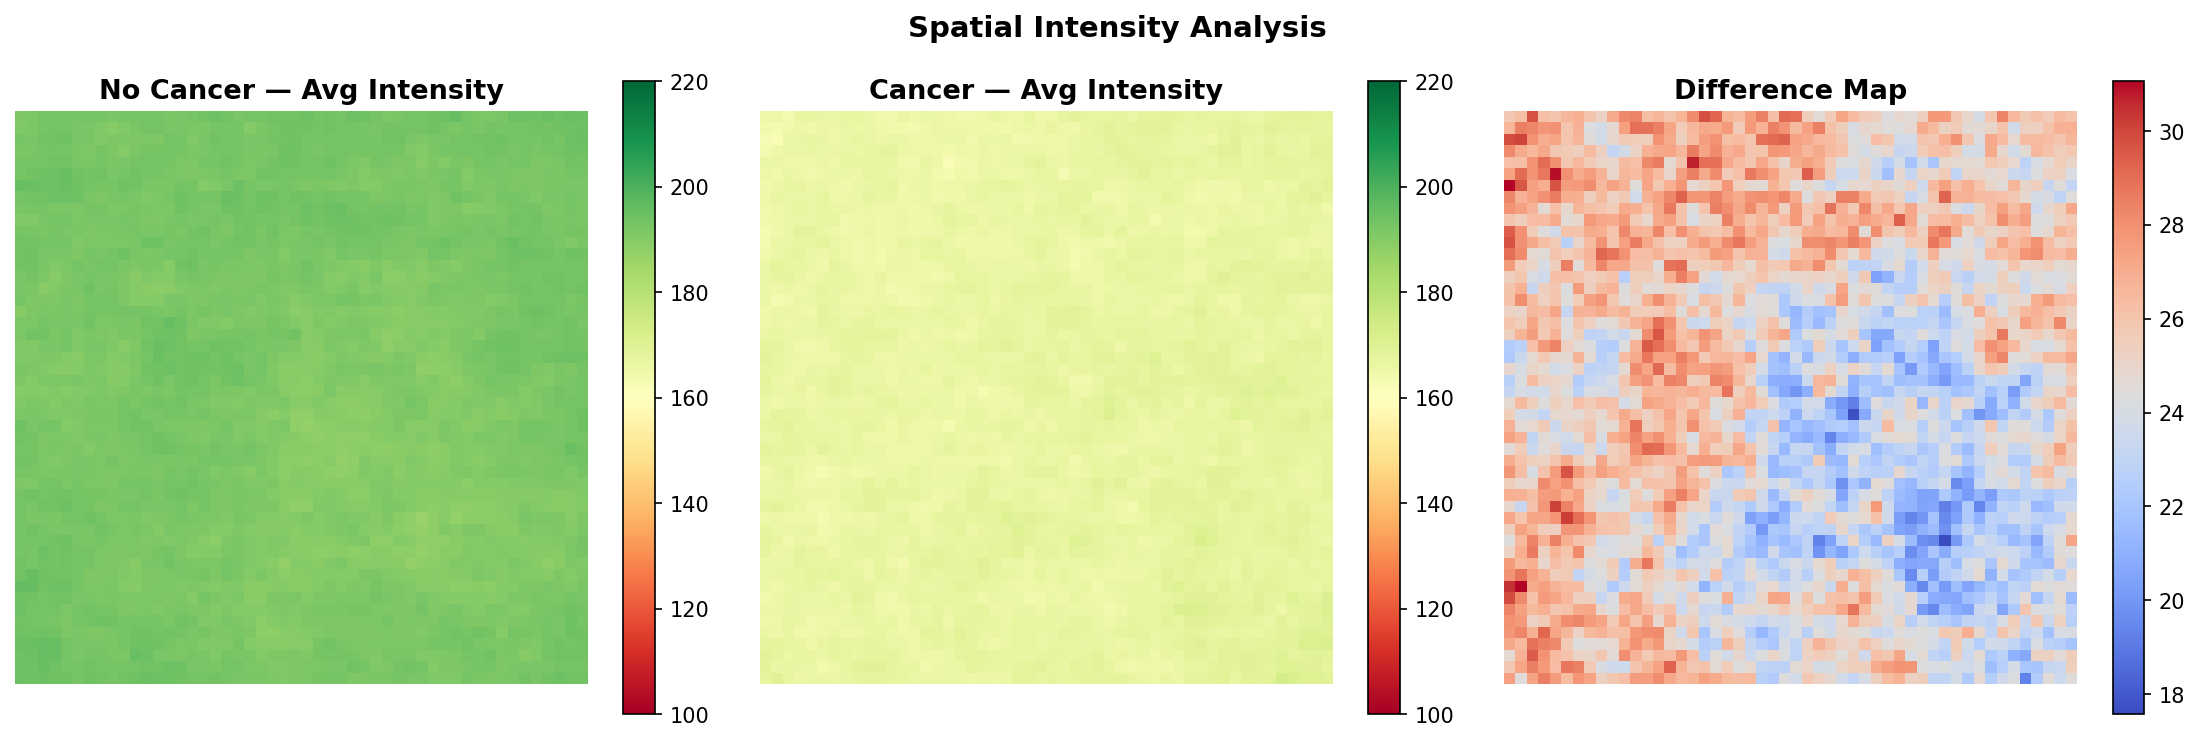

In [26]:
from IPython.display import Image
Image("/kaggle/working/eda_spatial.png")

Data Preprocessing & Feature Engineering

Step 1 — Normalization & Standardization verify karo:

In [27]:
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Sample image lo
sample_path = df[df["label"]==1].iloc[0]["path"]
img = PILImage.open(sample_path).convert("RGB").resize((50, 50))
arr = np.array(img)

print(f"📊 BEFORE Normalization:")
print(f"   Min pixel:  {arr.min()}")
print(f"   Max pixel:  {arr.max()}")
print(f"   Mean:       {arr.mean():.2f}")
print(f"   Dtype:      {arr.dtype}")

# Normalize 0-1
arr_norm = arr / 255.0

print(f"\n📊 AFTER Normalization (0-1):")
print(f"   Min pixel:  {arr_norm.min():.4f}")
print(f"   Max pixel:  {arr_norm.max():.4f}")
print(f"   Mean:       {arr_norm.mean():.4f}")
print(f"   Dtype:      {arr_norm.dtype}")

# ImageNet standardization
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std  = np.array([0.229, 0.224, 0.225])
arr_std = (arr_norm - imagenet_mean) / imagenet_std

print(f"\n📊 AFTER ImageNet Standardization:")
print(f"   Min:  {arr_std.min():.4f}")
print(f"   Max:  {arr_std.max():.4f}")
print(f"   Mean: {arr_std.mean():.4f}")

📊 BEFORE Normalization:
   Min pixel:  33
   Max pixel:  236
   Mean:       129.72
   Dtype:      uint8

📊 AFTER Normalization (0-1):
   Min pixel:  0.1294
   Max pixel:  0.9255
   Mean:       0.5087
   Dtype:      float64

📊 AFTER ImageNet Standardization:
   Min:  -1.4580
   Max:  2.2914
   Mean: 0.2624


Step 2 — Augmentation Pipeline banao aur verify karo:

In [28]:
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import random

def augment_image(img_array):
    img = PILImage.fromarray(img_array)
    
    # Random horizontal flip
    if random.random() > 0.5:
        img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
    
    # Random vertical flip
    if random.random() > 0.5:
        img = img.transpose(PILImage.FLIP_TOP_BOTTOM)
    
    # Random rotation 0, 90, 180, 270
    angle = random.choice([0, 90, 180, 270])
    img = img.rotate(angle)
    
    # Random brightness
    from PIL import ImageEnhance
    factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Brightness(img).enhance(factor)
    
    # Random contrast
    factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Contrast(img).enhance(factor)
    
    # Random color (important — G channel critical tha EDA mein)
    factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Color(img).enhance(factor)
    
    return np.array(img)

# Verify — ek image pe 8 augmentations dikhao
sample_path = df[df["label"]==1].sample(1, random_state=42).iloc[0]["path"]
original = np.array(PILImage.open(sample_path).convert("RGB").resize((50, 50)))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

axes[0, 0].imshow(original)
axes[0, 0].set_title("Original", fontweight="bold", color="blue")
axes[0, 0].axis("off")

for i in range(1, 10):
    row = i // 5
    col = i % 5
    aug = augment_image(original)
    axes[row, col].imshow(aug)
    axes[row, col].set_title(f"Aug {i}", fontsize=9)
    axes[row, col].axis("off")

plt.suptitle("Augmentation Pipeline — Cancer Image", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/augmentation_verify.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Augmentation pipeline ready")

✅ Augmentation pipeline ready


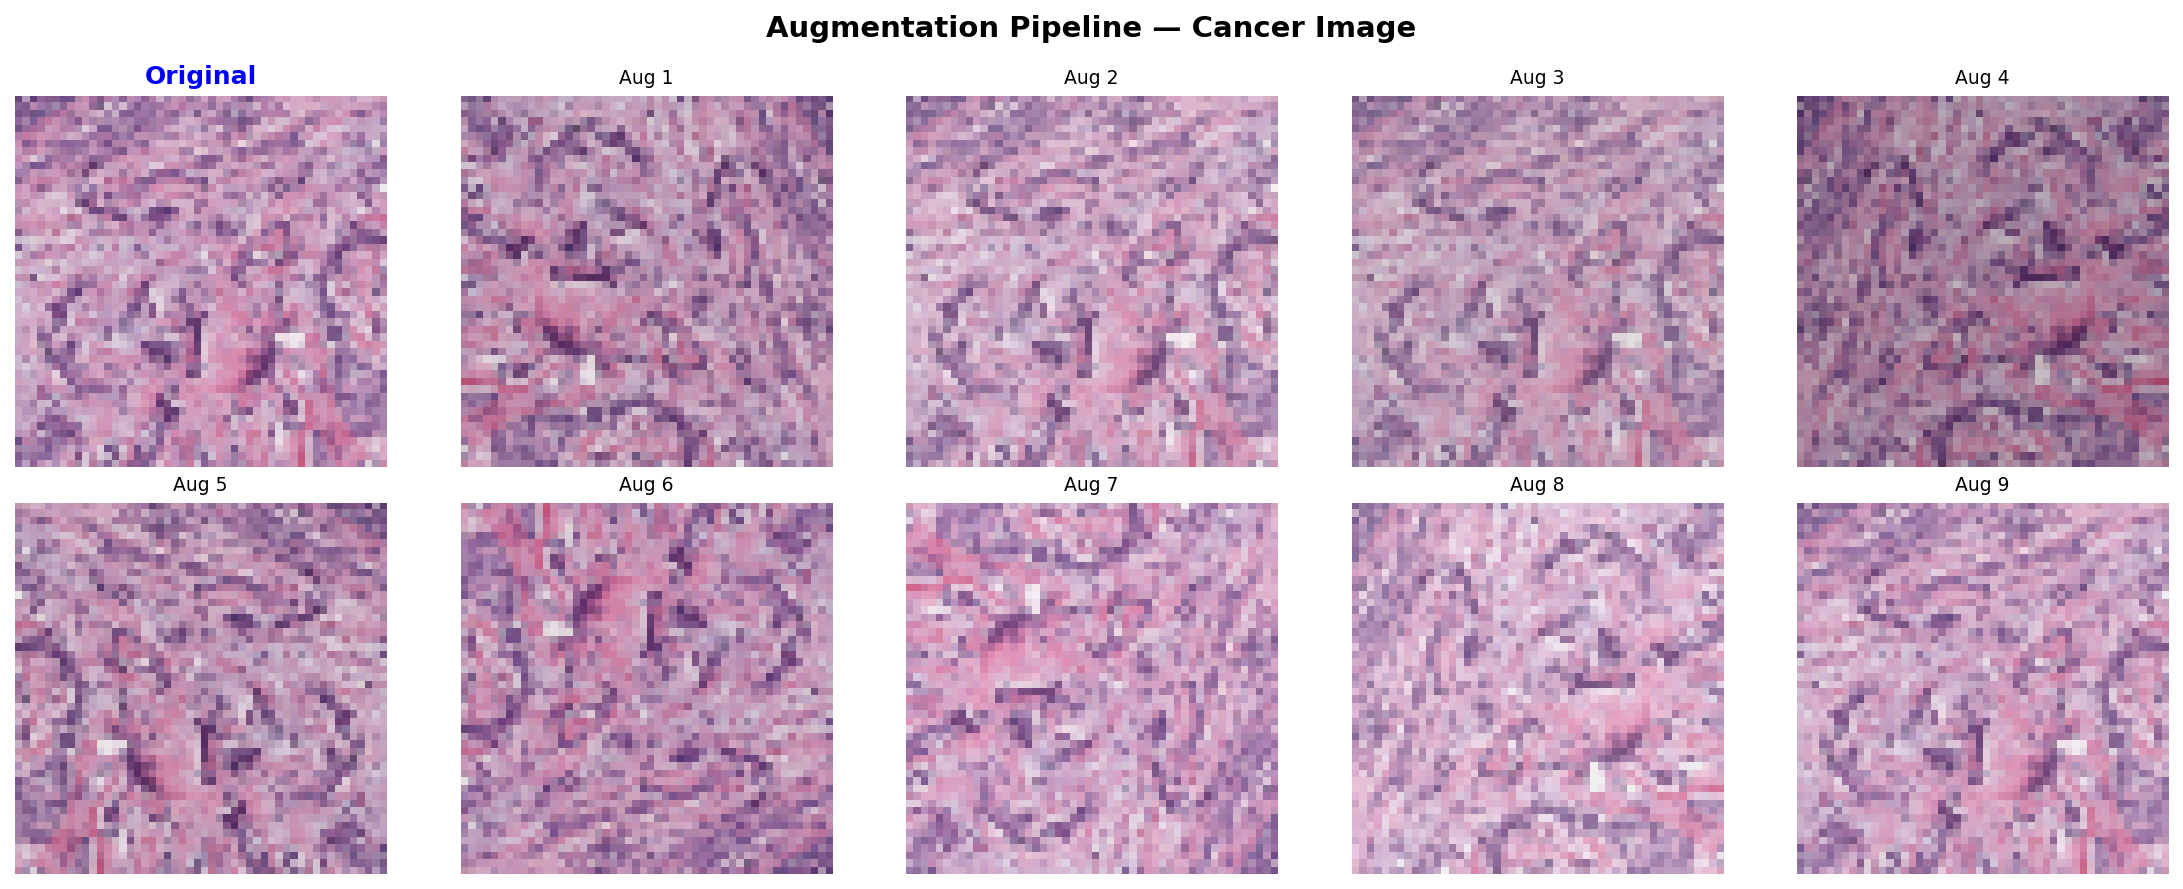

In [29]:
from IPython.display import Image
Image("/kaggle/working/augmentation_verify.png")

Step 3 — Final Preprocessing Verification

In [30]:
import numpy as np
from PIL import Image as PILImage, ImageEnhance
import random

def preprocess_image(path, augment=False):
    # Load & resize
    img = PILImage.open(path).convert("RGB").resize((50, 50))
    
    # Augment only for training
    if augment:
        if random.random() > 0.5:
            img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
        if random.random() > 0.5:
            img = img.transpose(PILImage.FLIP_TOP_BOTTOM)
        angle = random.choice([0, 90, 180, 270])
        img = img.rotate(angle)
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
        img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))
    
    # Normalize + Standardize
    arr = np.array(img, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    arr  = (arr - mean) / std
    
    return arr

# Test on 5 images
print(f"📊 PREPROCESSING VERIFICATION")
print(f"{'='*40}")

for i, (_, row) in enumerate(df.sample(5, random_state=42).iterrows()):
    arr = preprocess_image(row["path"], augment=True)
    print(f"Image {i+1} | Label: {row['label']} | Shape: {arr.shape} | Min: {arr.min():.2f} | Max: {arr.max():.2f} | Mean: {arr.mean():.2f}")

print(f"\n✅ Preprocessing pipeline ready!")
print(f"   Input shape:  (50, 50, 3)")
print(f"   Output range: standardized float32")
print(f"   Augmentation: 6 techniques applied")

📊 PREPROCESSING VERIFICATION
Image 1 | Label: 0 | Shape: (50, 50, 3) | Min: -1.83 | Max: 2.64 | Mean: 1.47
Image 2 | Label: 0 | Shape: (50, 50, 3) | Min: -1.53 | Max: 1.96 | Mean: 1.41
Image 3 | Label: 1 | Shape: (50, 50, 3) | Min: -1.23 | Max: 2.17 | Mean: 0.94
Image 4 | Label: 1 | Shape: (50, 50, 3) | Min: -1.00 | Max: 2.22 | Mean: 1.34
Image 5 | Label: 1 | Shape: (50, 50, 3) | Min: -0.76 | Max: 2.40 | Mean: 1.30

✅ Preprocessing pipeline ready!
   Input shape:  (50, 50, 3)
   Output range: standardized float32
   Augmentation: 6 techniques applied


Data Splitting shuru 

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/cleaned_dataset.csv")

# Unique patients lo
patients = df["patient_id"].unique()
print(f"Total patients: {len(patients)}")

# Patient level split — 70% train, 15% val, 15% test
train_patients, temp_patients = train_test_split(
    patients, test_size=0.30, random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.50, random_state=42
)

# DataFrame split
train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print(f"\n📊 SPLIT REPORT")
print(f"{'='*50}")
print(f"Train  — Patients: {len(train_patients):3d} | Images: {len(train_df):6,} | Cancer: {train_df['label'].sum():5,} ({train_df['label'].mean()*100:.1f}%)")
print(f"Val    — Patients: {len(val_patients):3d} | Images: {len(val_df):6,} | Cancer: {val_df['label'].sum():5,} ({val_df['label'].mean()*100:.1f}%)")
print(f"Test   — Patients: {len(test_patients):3d} | Images: {len(test_df):6,} | Cancer: {test_df['label'].sum():5,} ({test_df['label'].mean()*100:.1f}%)")

# Leakage verify
train_set = set(train_patients)
val_set   = set(val_patients)
test_set  = set(test_patients)

print(f"\n📊 LEAKAGE CHECK")
print(f"{'='*50}")
print(f"Train ∩ Val:   {len(train_set & val_set)} patients (must be 0)")
print(f"Train ∩ Test:  {len(train_set & test_set)} patients (must be 0)")
print(f"Val ∩ Test:    {len(val_set & test_set)} patients (must be 0)")

Total patients: 279

📊 SPLIT REPORT
Train  — Patients: 195 | Images: 193,343 | Cancer: 57,135 (29.6%)
Val    — Patients:  42 | Images: 41,402 | Cancer: 9,694 (23.4%)
Test   — Patients:  42 | Images: 42,779 | Cancer: 11,957 (28.0%)

📊 LEAKAGE CHECK
Train ∩ Val:   0 patients (must be 0)
Train ∩ Test:  0 patients (must be 0)
Val ∩ Test:    0 patients (must be 0)


Fix — Stratified Patient-wise Split:

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/cleaned_dataset.csv")

# Har patient ka cancer ratio nikalo
patient_stats = df.groupby("patient_id")["label"].mean().reset_index()
patient_stats.columns = ["patient_id", "cancer_ratio"]

# Cancer ratio ke basis pe stratify karo
patient_stats["strata"] = pd.cut(
    patient_stats["cancer_ratio"],
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=["low", "medium", "high", "very_high"]
)

print(f"Patient strata distribution:")
print(patient_stats["strata"].value_counts())

# Stratified split
train_patients, temp_patients = train_test_split(
    patient_stats["patient_id"],
    test_size=0.30,
    random_state=42,
    stratify=patient_stats["strata"]
)

temp_strata = patient_stats[patient_stats["patient_id"].isin(temp_patients)]["strata"]
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
    stratify=temp_strata
)

# DataFrame split
train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print(f"\n📊 STRATIFIED SPLIT REPORT")
print(f"{'='*55}")
print(f"Train  — Patients: {len(train_patients):3d} | Images: {len(train_df):6,} | Cancer: {train_df['label'].mean()*100:.1f}%")
print(f"Val    — Patients: {len(val_patients):3d} | Images: {len(val_df):6,} | Cancer: {val_df['label'].mean()*100:.1f}%")
print(f"Test   — Patients: {len(test_patients):3d} | Images: {len(test_df):6,} | Cancer: {test_df['label'].mean()*100:.1f}%")

# Leakage check
print(f"\n📊 LEAKAGE CHECK")
print(f"{'='*55}")
print(f"Train ∩ Val:   {len(set(train_patients) & set(val_patients))} (must be 0)")
print(f"Train ∩ Test:  {len(set(train_patients) & set(test_patients))} (must be 0)")
print(f"Val ∩ Test:    {len(set(val_patients) & set(test_patients))} (must be 0)")

Patient strata distribution:
strata
low          103
medium        90
high          60
very_high     26
Name: count, dtype: int64

📊 STRATIFIED SPLIT REPORT
Train  — Patients: 195 | Images: 192,857 | Cancer: 28.8%
Val    — Patients:  42 | Images: 42,982 | Cancer: 27.1%
Test   — Patients:  42 | Images: 41,685 | Cancer: 28.0%

📊 LEAKAGE CHECK
Train ∩ Val:   0 (must be 0)
Train ∩ Test:  0 (must be 0)
Val ∩ Test:    0 (must be 0)


Step 3 — Splits save karo aur final verify:

In [33]:
# Save splits
train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

# Final summary
total = len(train_df) + len(val_df) + len(test_df)

print(f"📊 FINAL DATA SPLIT SUMMARY")
print(f"{'='*55}")
print(f"Total images:     {total:,}")
print(f"")
print(f"Train:  {len(train_df):,} images ({len(train_df)/total*100:.1f}%) — {len(train_patients)} patients")
print(f"Val:    {len(val_df):,} images ({len(val_df)/total*100:.1f}%) — {len(val_patients)} patients")
print(f"Test:   {len(test_df):,} images ({len(test_df)/total*100:.1f}%) — {len(test_patients)} patients")
print(f"")
print(f"Cancer % consistency:")
print(f"  Train: {train_df['label'].mean()*100:.1f}%")
print(f"  Val:   {val_df['label'].mean()*100:.1f}%")
print(f"  Test:  {test_df['label'].mean()*100:.1f}%")
print(f"")
print(f"✅ train.csv saved — {len(train_df):,} images")
print(f"✅ val.csv   saved — {len(val_df):,} images")
print(f"✅ test.csv  saved — {len(test_df):,} images")
print(f"✅ No patient leakage")
print(f"✅ Stratified — cancer % consistent across splits")

📊 FINAL DATA SPLIT SUMMARY
Total images:     277,524

Train:  192,857 images (69.5%) — 195 patients
Val:    42,982 images (15.5%) — 42 patients
Test:   41,685 images (15.0%) — 42 patients

Cancer % consistency:
  Train: 28.8%
  Val:   27.1%
  Test:  28.0%

✅ train.csv saved — 192,857 images
✅ val.csv   saved — 42,982 images
✅ test.csv  saved — 41,685 images
✅ No patient leakage
✅ Stratified — cancer % consistent across splits


Model Selection
DenseNet121 + Custom Head ✅ — Best Choice

Step 1 — DenseNet121 load karo

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# DenseNet121 load karo pretrained ImageNet weights ke saath
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(50, 50, 3)
)

print(f"\n✅ DenseNet121 loaded!")
print(f"   Total layers:      {len(base_model.layers)}")
print(f"   Total parameters:  {base_model.count_params():,}")

2026-06-17 06:58:22.119117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781679502.293215      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781679502.341656      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781679502.782312      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781679502.782338      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781679502.782341      25 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


I0000 00:00:1781679515.161452      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781679515.167839      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✅ DenseNet121 loaded!
   Total layers:      427
   Total parameters:  7,037,504


Step 2 — Custom Head banao:

In [35]:
from tensorflow.keras import layers, Model
import tensorflow as tf

# Base model freeze karo pehle — sirf custom head train hoga
base_model.trainable = False

# Custom classification head
inputs = tf.keras.Input(shape=(50, 50, 3))
x = base_model(inputs, training=False)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Batch Normalization
x = layers.BatchNormalization()(x)

# Dense layer 1
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Dense layer 2
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Output layer — binary classification
outputs = layers.Dense(1, activation="sigmoid")(x)

# Final model
model = Model(inputs, outputs)

print(f"📊 MODEL SUMMARY")
print(f"{'='*50}")
print(f"Total layers:       {len(model.layers)}")
print(f"Total parameters:   {model.count_params():,}")
print(f"Trainable params:   {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Frozen params:      {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")
print(f"\n✅ Custom head ready!")
print(f"   Base: DenseNet121 (frozen)")
print(f"   Head: GAP → BN → Dense(256) → BN → Drop(0.4) → Dense(128) → BN → Drop(0.3) → Sigmoid")

📊 MODEL SUMMARY
Total layers:       11
Total parameters:   7,338,561
Trainable params:   298,241
Frozen params:      7,040,320

✅ Custom head ready!
   Base: DenseNet121 (frozen)
   Head: GAP → BN → Dense(256) → BN → Drop(0.4) → Dense(128) → BN → Drop(0.3) → Sigmoid


Step 3 — Focal Loss + Metrics define karo

In [36]:
import tensorflow as tf
import numpy as np

# Class weights calculate karo — imbalance handle karne ke liye
total = 277524
cancer = 78786
no_cancer = 198738

weight_for_0 = (1 / no_cancer) * (total / 2.0)
weight_for_1 = (1 / cancer) * (total / 2.0)

print(f"📊 CLASS WEIGHTS")
print(f"{'='*40}")
print(f"No Cancer weight: {weight_for_0:.4f}")
print(f"Cancer weight:    {weight_for_1:.4f}")
print(f"Ratio:            1 : {weight_for_1/weight_for_0:.2f}")

# Focal Loss define karo
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        focal_loss = alpha_t * tf.pow(1 - p_t, self.gamma) * bce
        return tf.reduce_mean(focal_loss)

# Model compile karo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=FocalLoss(alpha=0.25, gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print(f"\n✅ Model compiled!")
print(f"   Optimizer:   Adam (lr=0.001)")
print(f"   Loss:        Focal Loss (alpha=0.25, gamma=2.0)")
print(f"   Metrics:     AUC, Recall, Precision, Accuracy")

📊 CLASS WEIGHTS
No Cancer weight: 0.6982
Cancer weight:    1.7613
Ratio:            1 : 2.52

✅ Model compiled!
   Optimizer:   Adam (lr=0.001)
   Loss:        Focal Loss (alpha=0.25, gamma=2.0)
   Metrics:     AUC, Recall, Precision, Accuracy


Step 4 — Data Generator banao:

In [37]:
import tensorflow as tf
import pandas as pd
import numpy as np
from PIL import Image as PILImage, ImageEnhance
import random

class CancerDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, augment=False, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.mean = np.array([0.485, 0.456, 0.406])
        self.std  = np.array([0.229, 0.224, 0.225])
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_idx]
        images, labels = [], []
        for _, row in batch.iterrows():
            try:
                img = PILImage.open(row["path"]).convert("RGB").resize((50, 50))
                if self.augment:
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_TOP_BOTTOM)
                    img = img.rotate(random.choice([0, 90, 180, 270]))
                    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = (arr - self.mean) / self.std
                images.append(arr)
                labels.append(float(row["label"]))
            except:
                images.append(np.zeros((50, 50, 3), dtype=np.float32))
                labels.append(0.0)
        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Load splits
train_df = pd.read_csv("/kaggle/working/train.csv")
val_df   = pd.read_csv("/kaggle/working/val.csv")
test_df  = pd.read_csv("/kaggle/working/test.csv")

# Generators banao
train_gen = CancerDataGenerator(train_df, batch_size=32, augment=True,  shuffle=True)
val_gen   = CancerDataGenerator(val_df,   batch_size=32, augment=False, shuffle=False)
test_gen  = CancerDataGenerator(test_df,  batch_size=32, augment=False, shuffle=False)

# Verify
x, y = train_gen[0]
print(f"📊 GENERATOR VERIFICATION")
print(f"{'='*40}")
print(f"Batch shape:     {x.shape}")
print(f"Labels shape:    {y.shape}")
print(f"Image min:       {x.min():.3f}")
print(f"Image max:       {x.max():.3f}")
print(f"Cancer in batch: {int(y.sum())}/{len(y)}")
print(f"Train batches:   {len(train_gen):,}")
print(f"Val batches:     {len(val_gen):,}")
print(f"Test batches:    {len(test_gen):,}")
print(f"\n✅ Data generators ready!")

📊 GENERATOR VERIFICATION
Batch shape:     (32, 50, 50, 3)
Labels shape:    (32,)
Image min:       -2.036
Image max:       2.640
Cancer in batch: 8/32
Train batches:   6,027
Val batches:     1,344
Test batches:    1,303

✅ Data generators ready!


Step 5 — Callbacks define karo:

In [38]:
import tensorflow as tf
import os

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

callbacks = [
    # Best model save karo
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/best_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # Learning rate reduce karo jab improvement na ho
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # Early stopping — overfit rokne ke liye
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Training log save karo
    tf.keras.callbacks.CSVLogger(
        "/kaggle/working/training_log.csv",
        append=True
    )
]

print(f"📊 CALLBACKS READY")
print(f"{'='*40}")
print(f"✅ ModelCheckpoint — best val_auc save hoga")
print(f"✅ ReduceLROnPlateau — patience=3, factor=0.3")
print(f"✅ EarlyStopping — patience=5")
print(f"✅ CSVLogger — training log save hoga")

📊 CALLBACKS READY
✅ ModelCheckpoint — best val_auc save hoga
✅ ReduceLROnPlateau — patience=3, factor=0.3
✅ EarlyStopping — patience=5
✅ CSVLogger — training log save hoga


Ab sab ready hai — Training shuru karte hain!
Phase 1 — Frozen Base Training:

In [39]:
import tensorflow as tf

# Phase 1 — Sirf custom head train karo
print(f"🚀 PHASE 1 TRAINING — Frozen Base")
print(f"{'='*40}")
print(f"Epochs:      10")
print(f"Batch size:  32")
print(f"LR:          0.001")
print(f"Base:        Frozen")
print(f"")

history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    class_weight={
        0: 0.6982,
        1: 1.7613
    },
    verbose=1
)

print(f"\n✅ Phase 1 Complete!")

🚀 PHASE 1 TRAINING — Frozen Base
Epochs:      10
Batch size:  32
LR:          0.001
Base:        Frozen

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1781679551.591785      76 service.cc:152] XLA service 0x7a6b58023460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781679551.591820      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781679551.591824      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781679555.079372      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


   4/6027 ━━━━━━━━━━━━━━━━━━━━ 4:54 49ms/step - accuracy: 0.4857 - auc: 0.4595 - loss: 0.3546 - precision: 0.2344 - recall: 0.4042

I0000 00:00:1781679565.793666      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6027/6027 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6907 - auc: 0.5083 - loss: 0.0796 - precision: 0.2593 - recall: 0.0428
Epoch 1: val_auc improved from None to 0.41816, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/best_model.keras
6027/6027 ━━━━━━━━━━━━━━━━━━━━ 521s 82ms/step - accuracy: 0.7070 - auc: 0.5031 - loss: 0.0648 - precision: 0.2568 - recall: 0.0100 - val_accuracy: 0.7286 - val_auc: 0.4182 - val_loss: 0.0576 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
6027/6027 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7117 - auc: 0.5010 - loss: 0.0601 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_auc did not improve from 0.41816
6027/6027 ━━━━━━━━━━━━━━━━━━━━ 353s 59ms/step - accuracy: 0.7124 - auc: 0.5000 - loss: 0.0600 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7286 - val_auc: 0.3732 - val_loss: 0.0577 - val_precision: 0.00

In [40]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

# Model dobara banao — 96x96 input size
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

# Binary Crossentropy — Focal Loss ki jagah
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print(f"✅ Model rebuilt!")
print(f"   Input size:   96x96")
print(f"   LR:           0.0001")
print(f"   Loss:         BinaryCrossentropy")
print(f"   Trainable:    {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

✅ Model rebuilt!
   Input size:   96x96
   LR:           0.0001
   Loss:         BinaryCrossentropy
   Trainable:    297,985


In [41]:
import tensorflow as tf
import pandas as pd
import numpy as np
from PIL import Image as PILImage, ImageEnhance
import random, os

class CancerDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, augment=False, shuffle=True, img_size=96):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.img_size = img_size
        self.indexes = np.arange(len(self.df))
        self.mean = np.array([0.485, 0.456, 0.406])
        self.std  = np.array([0.229, 0.224, 0.225])
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_idx]
        images, labels = [], []
        for _, row in batch.iterrows():
            try:
                img = PILImage.open(row["path"]).convert("RGB").resize((self.img_size, self.img_size))
                if self.augment:
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_TOP_BOTTOM)
                    img = img.rotate(random.choice([0, 90, 180, 270]))
                    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = (arr - self.mean) / self.std
                images.append(arr)
                labels.append(float(row["label"]))
            except:
                images.append(np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
                labels.append(0.0)
        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

train_df = pd.read_csv("/kaggle/working/train.csv")
val_df   = pd.read_csv("/kaggle/working/val.csv")
test_df  = pd.read_csv("/kaggle/working/test.csv")

train_gen = CancerDataGenerator(train_df, batch_size=32, augment=True,  shuffle=True,  img_size=96)
val_gen   = CancerDataGenerator(val_df,   batch_size=32, augment=False, shuffle=False, img_size=96)
test_gen  = CancerDataGenerator(test_df,  batch_size=32, augment=False, shuffle=False, img_size=96)

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/best_model.keras",
        monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max",
        factor=0.3, patience=3,
        min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger("/kaggle/working/training_log.csv")
]

x, y = train_gen[0]
print(f"✅ Generators ready!")
print(f"   Batch shape:   {x.shape}")
print(f"   Train batches: {len(train_gen):,}")
print(f"   Val batches:   {len(val_gen):,}")

✅ Generators ready!
   Batch shape:   (32, 96, 96, 3)
   Train batches: 6,027
   Val batches:   1,344


In [42]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Check karo CSVs already hain ya nahi
if os.path.exists("/kaggle/working/train.csv"):
    train_df = pd.read_csv("/kaggle/working/train.csv")
    val_df   = pd.read_csv("/kaggle/working/val.csv")
    test_df  = pd.read_csv("/kaggle/working/test.csv")
    print(f"✅ CSVs already exist!")
    print(f"   Train: {len(train_df):,}")
    print(f"   Val:   {len(val_df):,}")
    print(f"   Test:  {len(test_df):,}")
else:
    print("❌ CSVs nahi hain — rebuild karna hoga")

✅ CSVs already exist!
   Train: 192,857
   Val:   42,982
   Test:  41,685


In [43]:
import os   
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Check karo CSVs already hain ya nahi
if os.path.exists("/kaggle/working/train.csv"):
    train_df = pd.read_csv("/kaggle/working/train.csv")
    val_df   = pd.read_csv("/kaggle/working/val.csv")
    test_df  = pd.read_csv("/kaggle/working/test.csv")
    print(f"✅ CSVs already exist!")
    print(f"   Train: {len(train_df):,}")
    print(f"   Val:   {len(val_df):,}")
    print(f"   Test:  {len(test_df):,}")
else:
    print("❌ CSVs nahi hain — rebuild karna hoga")

✅ CSVs already exist!
   Train: 192,857
   Val:   42,982
   Test:  41,685


In [44]:
import tensorflow as tf
import pandas as pd
import numpy as np
from PIL import Image as PILImage, ImageEnhance
import random, os
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

class CancerDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, augment=False, shuffle=True, img_size=96):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.img_size = img_size
        self.indexes = np.arange(len(self.df))
        self.mean = np.array([0.485, 0.456, 0.406])
        self.std  = np.array([0.229, 0.224, 0.225])
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_idx]
        images, labels = [], []
        for _, row in batch.iterrows():
            try:
                img = PILImage.open(row["path"]).convert("RGB").resize((self.img_size, self.img_size))
                if self.augment:
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_TOP_BOTTOM)
                    img = img.rotate(random.choice([0, 90, 180, 270]))
                    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = (arr - self.mean) / self.std
                images.append(arr)
                labels.append(float(row["label"]))
            except:
                images.append(np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
                labels.append(0.0)
        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

train_df = pd.read_csv("/kaggle/working/train.csv")
val_df   = pd.read_csv("/kaggle/working/val.csv")
test_df  = pd.read_csv("/kaggle/working/test.csv")

train_gen = CancerDataGenerator(train_df, batch_size=32, augment=True,  shuffle=True,  img_size=96)
val_gen   = CancerDataGenerator(val_df,   batch_size=32, augment=False, shuffle=False, img_size=96)
test_gen  = CancerDataGenerator(test_df,  batch_size=32, augment=False, shuffle=False, img_size=96)

base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/best_model.keras",
        monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max",
        factor=0.3, patience=3,
        min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger("/kaggle/working/training_log.csv")
]

print(f"✅ Everything ready!")
print(f"   Train batches: {len(train_gen):,}")
print(f"   Val batches:   {len(val_gen):,}")

print(f"\n🚀 PHASE 1 TRAINING START")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    class_weight={0: 0.70, 1: 1.76},
    verbose=1
)

✅ Everything ready!
   Train batches: 6,027
   Val batches:   1,344

🚀 PHASE 1 TRAINING START
Epoch 1/15
6027/6027 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7814 - auc: 0.8634 - loss: 0.4843 - precision: 0.5898 - recall: 0.8004
Epoch 1: val_auc improved from None to 0.91684, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/best_model.keras
6027/6027 ━━━━━━━━━━━━━━━━━━━━ 518s 82ms/step - accuracy: 0.8052 - auc: 0.8862 - loss: 0.4396 - precision: 0.6223 - recall: 0.8205 - val_accuracy: 0.8092 - val_auc: 0.9168 - val_loss: 0.4054 - val_precision: 0.6011 - val_recall: 0.8831 - learning_rate: 1.0000e-04
Epoch 2/15
6027/6027 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8278 - auc: 0.9092 - loss: 0.3869 - precision: 0.6539 - recall: 0.8480
Epoch 2: val_auc improved from 0.91684 to 0.92228, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 2: finished saving model to /kaggle/working/checkpoint

In [45]:
import os
if os.path.exists("/kaggle/working/checkpoints/best_model.keras"):
    print("✅ Saved model exist karta hai!")
else:
    print("❌ Model nahi mila — dobara shuru se chalana hoga")

✅ Saved model exist karta hai!


In [46]:
import os
print(f"Output space available:")
os.system("df -h /kaggle/working")

# Check karo kitna space hai
total, used, free = os.popen("df /kaggle/working").readlines()[1].split()[1:4]
print(f"Total: {int(total)//1024} MB")
print(f"Used:  {int(used)//1024} MB") 
print(f"Free:  {int(free)//1024} MB")

Output space available:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  172M   20G   1% /kaggle/working
Total: 19986 MB
Used:  171 MB
Free:  19799 MB


In [47]:
import tensorflow as tf
import pandas as pd
import numpy as np
from PIL import Image as PILImage, ImageEnhance
import random, os
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

class CancerDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=64, augment=False, shuffle=True, img_size=96):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.img_size = img_size
        self.indexes = np.arange(len(self.df))
        self.mean = np.array([0.485, 0.456, 0.406])
        self.std  = np.array([0.229, 0.224, 0.225])
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_idx]
        images, labels = [], []
        for _, row in batch.iterrows():
            try:
                img = PILImage.open(row["path"]).convert("RGB").resize((self.img_size, self.img_size))
                if self.augment:
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        img = img.transpose(PILImage.FLIP_TOP_BOTTOM)
                    img = img.rotate(random.choice([0, 90, 180, 270]))
                    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = (arr - self.mean) / self.std
                images.append(arr)
                labels.append(float(row["label"]))
            except:
                images.append(np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
                labels.append(0.0)
        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Load data
train_df = pd.read_csv("/kaggle/working/train.csv")
val_df   = pd.read_csv("/kaggle/working/val.csv")
test_df  = pd.read_csv("/kaggle/working/test.csv")

train_gen = CancerDataGenerator(train_df, batch_size=64, augment=True,  shuffle=True,  img_size=96)
val_gen   = CancerDataGenerator(val_df,   batch_size=64, augment=False, shuffle=False, img_size=96)
test_gen  = CancerDataGenerator(test_df,  batch_size=64, augment=False, shuffle=False, img_size=96)

# Model
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

# Callbacks — har epoch ke baad save hoga
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
callbacks = [
    # Best model save
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/best_model.keras",
        monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
    # Har epoch save — backup
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/epoch_{epoch:02d}.keras",
        monitor="val_auc", mode="max",
        save_best_only=False, verbose=0),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max",
        factor=0.3, patience=3,
        min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(
        "/kaggle/working/training_log.csv")
]

print(f"✅ Ready!")
print(f"   Train batches: {len(train_gen):,}")
print(f"   Val batches:   {len(val_gen):,}")
print(f"   Batch size:    64")

print(f"\n🚀 TRAINING START — Epoch 1/15")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    class_weight={0: 0.70, 1: 1.76},
    verbose=1
)

print("\n✅ TRAINING COMPLETE!")
print(f"Best Val AUC: {max(history.history['val_auc']):.4f}")

✅ Ready!
   Train batches: 3,014
   Val batches:   672
   Batch size:    64

🚀 TRAINING START — Epoch 1/15
Epoch 1/15
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7576 - auc: 0.8507 - loss: 0.5213 - precision: 0.5617 - recall: 0.8137
Epoch 1: val_auc improved from None to 0.91358, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/best_model.keras
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 510s 160ms/step - accuracy: 0.7960 - auc: 0.8797 - loss: 0.4588 - precision: 0.6071 - recall: 0.8230 - val_accuracy: 0.8188 - val_auc: 0.9136 - val_loss: 0.3950 - val_precision: 0.6190 - val_recall: 0.8647 - learning_rate: 1.0000e-04
Epoch 2/15
3014/3014 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8240 - auc: 0.9066 - loss: 0.3945 - precision: 0.6496 - recall: 0.8434
Epoch 2: val_auc improved from 0.91358 to 0.92095, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 2: finished saving model to /kaggle/wo

In [48]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
import os

# ============ DATA ============
base = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"
all_images = []
for patient in os.listdir(base):
    for label in ["0", "1"]:
        folder = os.path.join(base, patient, label)
        if os.path.exists(folder):
            for img in os.listdir(folder):
                if img.endswith(".png"):
                    all_images.append({
                        "path": os.path.join(folder, img),
                        "patient_id": patient,
                        "label": int(label)
                    })

df = pd.DataFrame(all_images)
patient_stats = df.groupby("patient_id")["label"].mean().reset_index()
patient_stats.columns = ["patient_id", "cancer_ratio"]
patient_stats["strata"] = pd.cut(
    patient_stats["cancer_ratio"],
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=["low", "medium", "high", "very_high"]
)

train_p, temp_p = train_test_split(
    patient_stats["patient_id"], test_size=0.30,
    random_state=42, stratify=patient_stats["strata"]
)
temp_s = patient_stats[patient_stats["patient_id"].isin(temp_p)]["strata"]
val_p, test_p = train_test_split(
    temp_p, test_size=0.50, random_state=42, stratify=temp_s
)

train_df = df[df["patient_id"].isin(train_p)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_p)].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(test_p)].reset_index(drop=True)
print(f"✅ Data: Train={len(train_df):,} Val={len(val_df):,} Test={len(test_df):,}")

# ============ TF DATASET ============
IMG_SIZE = 96
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    mean = tf.constant([0.485, 0.456, 0.406])
    std  = tf.constant([0.229, 0.224, 0.225])
    img  = (img - mean) / std
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
    return img, label

def make_dataset(df, augment=False, shuffle=False):
    paths  = df["path"].values
    labels = df["label"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=5000, seed=42)
    ds = ds.map(
        lambda x, y: load_image(x, y, augment=augment),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment=False, shuffle=False)
print(f"✅ TF Datasets ready!")

# ============ MODEL ============
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)
print(f"✅ Model ready: {model.count_params():,} params")

# ============ PHASE 1 ============
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/best_model.keras",
        monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max",
        factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger("/kaggle/working/training_log_p1.csv")
]

print(f"\n🚀 PHASE 1 START!")
history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_p1,
    class_weight={0: 0.70, 1: 1.76},
    verbose=1
)
p1_auc = max(history_p1.history['val_auc'])
print(f"✅ PHASE 1 COMPLETE! Best Val AUC: {p1_auc:.4f}")

# ============ PHASE 2 ============
model.layers[1].trainable = True
for layer in model.layers[1].layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/checkpoints/best_model_ft.keras",
        monitor="val_auc", mode="max",
        save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max",
        factor=0.3, patience=2, min_lr=1e-8, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger("/kaggle/working/training_log_ft.csv")
]

print(f"\n🚀 PHASE 2 FINE TUNING START!")
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_p2,
    class_weight={0: 0.70, 1: 1.76},
    verbose=1
)

print(f"\n🎉 ALL TRAINING COMPLETE!")
print(f"   Phase 1 Best Val AUC: {p1_auc:.4f}")
print(f"   Phase 2 Best Val AUC: {max(history_ft.history['val_auc']):.4f}")
print(f"   Phase 2 Best Recall:  {max(history_ft.history['val_recall']):.4f}")

# Model save
model.save("/kaggle/working/final_cancer_model.keras")
print(f"✅ Final model saved!")

✅ Data: Train=197,979 Val=38,699 Test=40,846
✅ TF Datasets ready!
✅ Model ready: 7,338,049 params

🚀 PHASE 1 START!
Epoch 1/15
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7655 - auc: 0.8389 - loss: 0.5153 - precision: 0.5460 - recall: 0.7682
Epoch 1: val_auc improved from None to 0.90916, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/best_model.keras
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 208s 115ms/step - accuracy: 0.7973 - auc: 0.8705 - loss: 0.4711 - precision: 0.6010 - recall: 0.7897 - val_accuracy: 0.8094 - val_auc: 0.9092 - val_loss: 0.4370 - val_precision: 0.6603 - val_recall: 0.8793 - learning_rate: 1.0000e-04
Epoch 2/15
1546/1547 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8098 - auc: 0.8935 - loss: 0.4142 - precision: 0.6056 - recall: 0.8328
Epoch 2: val_auc improved from 0.90916 to 0.91433, saving model to /kaggle/working/checkpoints/best_model.keras

Epoch 2: finished saving model to /ka

In [49]:
import os

# Check karo files exist karti hain
files = [
    "/kaggle/working/final_cancer_model.keras",
    "/kaggle/working/checkpoints/best_model_ft.keras",
    "/kaggle/working/checkpoints/best_model.keras"
]

print("📊 MODEL FILES CHECK")
print("="*50)
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024*1024)
        print(f"✅ {f.split('/')[-1]} — {size:.1f} MB")
    else:
        print(f"❌ {f.split('/')[-1]} — NOT FOUND")

📊 MODEL FILES CHECK
✅ final_cancer_model.keras — 40.0 MB
✅ best_model_ft.keras — 40.0 MB
✅ best_model.keras — 31.7 MB
